
# Non-Hermitian many-body localization as a quantum reservoir
### Classically-simulated prototype (N=8 spins)  

**The gap this targets:** non-Hermitian MBL (real-vs-complex spectral transitions tied to
localization, PT-symmetry breaking, the non-Hermitian skin effect) is an active field on
its own. Reservoir computing / ML-based phase diagnosis is an active field on its own.
A literature check found no paper combining them : non-Hermitian skin-effect reservoirs
that exist so far are either architectural (a QNN built to *have* a skin effect) or
free-fermion ("Fermi skin" on real hardware), not an *interacting, disordered* non-Hermitian
chain used as a reservoir to diagnose its own localization transition.

**Same caveat as the Hermitian version:** this notebook simulates everything classically
(exact diagonalization, N=8). It cannot and does not demonstrate quantum advantage. What
it *can* demonstrate is a real, reproducible methodological point : and a non-Hermitian-specific
one that has no analog in the Hermitian case  


In [ ]:
!pip install shap

In [ ]:

import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.linalg import eig
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sx = np.array([[0, 1], [1, 0]], dtype=complex) / 2
sy = np.array([[0, -1j], [1j, 0]], dtype=complex) / 2
sz = np.array([[1, 0], [0, -1]], dtype=complex) / 2
sp, sm = sx + 1j * sy, sx - 1j * sy
I2 = np.eye(2, dtype=complex)



## 1. The model : an interacting, disordered Hatano–Nelson chain

$$ H = \sum_{\langle i,j\rangle} \Big[J e^{g} S^+_i S^-_j + J e^{-g} S^-_i S^+_j + J\Delta\, S^z_i S^z_j\Big] + \sum_i h_i S^z_i,\qquad h_i\sim U[-W,W] $$

on a **ring** (periodic boundary conditions), with non-reciprocal hopping controlled by $g$
($g=0$ recovers the ordinary Hermitian MBL chain).

 **the non-Hermitian analog of the symmetry-sector
pitfall from before :** under *open* boundary conditions, this exact asymmetric-hopping
construction can be removed entirely by a (non-unitary) similarity transform : a textbook
fact about the single-particle Hatano–Nelson model that survives in the many-body case
because the $S^z_iS^z_j$ interaction is diagonal in the same basis the transform acts on.  The non-Hermitian content of this model is a **ring-only**
effect : that's why PBC is hard-coded below, not a stylistic choice.

We track total $S^z$ : still an exact symmetry, conserved by both the hopping and the
interaction term , and again restrict level-statistics diagnostics to the
$S^z=0$ sector.


In [ ]:

def op_on_site(op, site, N):
    mats = [I2] * N
    mats[site] = op
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

def build_H_NH(h, N, g, J=1.0, Delta=1.0, pbc=True):
    dim = 2 ** N
    H = np.zeros((dim, dim), dtype=complex)
    Sp = [op_on_site(sp, i, N) for i in range(N)]
    Sm = [op_on_site(sm, i, N) for i in range(N)]
    Sz = [op_on_site(sz, i, N) for i in range(N)]
    bonds = list(range(N - 1)) + ([N - 1] if pbc else [])
    for i in bonds:
        j = (i + 1) % N
        H += J * np.exp(g) * Sp[i] @ Sm[j] + J * np.exp(-g) * Sm[i] @ Sp[j]
        H += J * Delta * Sz[i] @ Sz[j]
    for i in range(N):
        H += h[i] * Sz[i]
    return H, Sz

def sector_indices(N):
    dim = 2 ** N
    return [i for i in range(dim) if bin(i).count('1') == N // 2]

def neel_index(N):
    return sum((1 if i % 2 == 0 else 0) << i for i in range(N))



## 2. Ground truth: the real-complex (RC) spectral transition

For this time reversal symmetric non-Hermitian family, the literature (Hamazaki et al.,
and follow-ups on long-range models) shows the fraction of **real** eigenvalues acts as an
order parameter that tracks the ergodic MBL transition: strong disorder suppresses the
imaginary parts of the spectrum and restores a real spectrum, even though $g\neq0$.
We use the disorder-averaged real fraction $\overline{f_{\rm real}}(W)$ and its crossing
through 0.5 as the (finite-size) pseudo-critical point, exactly mirroring how we used the
level-statistics ratio $\bar r(W)$ in the Hermitian.


In [ ]:
def build_dataset(
    N=10,
    g=0.3,
    W_list=(0.2,0.5,1,1.5,2,3,4,6,10),
    n_real=30,
    seed=0,
    meas_sites=None,
    meas_times=(0,1,2,4,8),
    include_survival=True,
    cond_threshold=1e10
):

    rng = np.random.default_rng(seed)

    if meas_sites is None:
        meas_sites = [0, N//2]

    dim = 2**N
    idx0 = neel_index(N)
    sec_idx = sector_indices(N)

    rows_feat = []
    rows_oracle = []
    rows_fr = []
    rows_W = []

    skipped_ep = 0

    for W in W_list:

        for _ in range(n_real):

            h = rng.uniform(-W, W, size=N)

            H, Sz = build_H_NH(h, N, g)


            # Ground-truth diagnostic (Sz = 0 sector)


            Hsub = H[np.ix_(sec_idx, sec_idx)]

            evals_sub = eig(Hsub, right=False)

            frac_real = np.mean(np.abs(evals_sub.imag) < 1e-8)


            # Reservoir dynamics


            evals, V = eig(H)

            #   Numerical stability guard
            condV = np.linalg.cond(V)

            if not np.isfinite(condV) or condV > cond_threshold:
                skipped_ep += 1
                continue

            psi0 = np.zeros(dim, dtype=complex)
            psi0[idx0] = 1.0

            c = np.linalg.solve(V, psi0)

            feat = []

            for tt in meas_times:

                psi_t = V @ (np.exp(-1j * evals * tt) * c)

                norm2 = np.real(psi_t.conj() @ psi_t)

                if include_survival:
                    feat.append(np.log(norm2 + 1e-300))

                for site in meas_sites:

                    val = (
                        np.real(psi_t.conj() @ (Sz[site] @ psi_t))
                        / norm2
                    )

                    feat.append(val)

            oracle = [
                h.mean(),
                h.std(),
                h.min(),
                h.max()
            ]

            rows_feat.append(feat)
            rows_oracle.append(oracle)
            rows_fr.append(frac_real)
            rows_W.append(W)

    print(
        f"Skipped {skipped_ep} realization(s) "
        f"due to ill-conditioned eigenvector matrices "
        f"(cond(V) > {cond_threshold:.1e})."
    )

    return (
        np.array(rows_feat),
        np.array(rows_oracle),
        np.array(rows_fr),
        np.array(rows_W)
    )


## 3. Reservoir features: local measurements *and* the survival-probability channel

Non-Hermitian dynamics has something the Hermitian reservoir doesn't: norm isn't conserved.
Physically this corresponds to a continuously-monitored open system, conditioned on no
quantum jump having occurred (a standard "no-click" trajectory interpretation) — the decay
or growth of the post-selection probability over time is itself an experimentally
accessible, model-free witness of which phase you're in (bounded/oscillatory in the
real-spectrum/localized phase, exponential in the complex-spectrum/delocalized phase),
with no analog in the ordinary unitary-MBL setting. We include it as one of the reservoir
output channels alongside the same local $\langle S^z_i(t)\rangle$ measurements as before.

Same three-way comparison as the Hermitian notebook, for the same reasons:
- **reservoir** — quench dynamics, a couple of sites, plus the survival-probability channel.
- **oracle** — direct access to the disorder values (unrealistic upper bound).
- **no-dynamics control** — same channels at $t=0$ only (deterministic, so should sit at
  the majority-class baseline if the pipeline has no leak).


Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Majority-class baseline             Accuracy = 0.556
Reservoir (dynamics + survival)     Accuracy = 0.938
Cross-validation (5-fold): 0.941 ± 0.022
Oracle (direct disorder statistics) Accuracy = 0.963
Cross-validation (5-fold): 0.981 ± 0.017
No-dynamics control                 Accuracy = 0.543
Cross-validation (5-fold): 0.533 ± 0.043


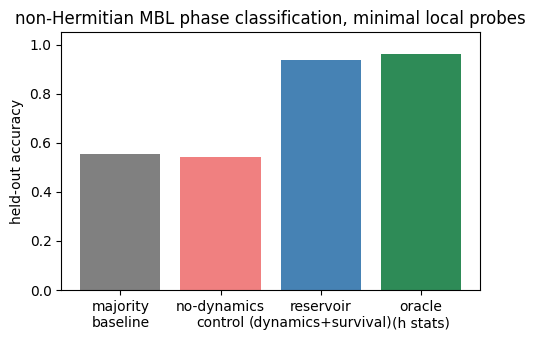

In [ ]:
N = 8
g = 0.3

# Call build_dataset to generate the data
X_res, X_oracle, y_fr, y_W = build_dataset(
    N=N,
    g=g,
    n_real=30,
)

# Determine W_star from the fraction of real eigenvalues
# This involves grouping y_fr by y_W and finding the W where the mean y_fr crosses 0.5
W_unique = np.sort(np.unique(y_W))
fr_mean = []
for W_val in W_unique:
    fr_mean.append(np.mean(y_fr[y_W == W_val]))


fr_mean = np.array(fr_mean)

# Find the first W where fr_mean drops below 0.5 (or rises above, depending on the ordering)
W_star = None
# Assuming fr_mean is generally decreasing with W for a transition from real to complex
for i in range(len(W_unique) - 1):
    if (fr_mean[i] >= 0.5 and fr_mean[i+1] < 0.5) or (fr_mean[i] < 0.5 and fr_mean[i+1] >= 0.5):
        # Linear interpolation
        w1, w2 = W_unique[i], W_unique[i+1]
        fr1, fr2 = fr_mean[i], fr_mean[i+1]
        W_star = w1 + (0.5 - fr1) * (w2 - w1) / (fr2 - fr1)
        break


if W_star is None:

    W_star = (W_unique.min() + W_unique.max()) / 2
    print(f"Warning: Could not find a clear 0.5 crossing for frac_real. Using W_star = {W_star:.2f} as a fallback.")

# Define y_phase based on W_star
# Assuming 'localized' corresponds to W > W_star
y_phase = (y_W > W_star).astype(int)

n_feat_per_t = 1 + 2
X_static = X_res[:, :n_feat_per_t]


#   classifier evaluation


def eval_classifier(Xf, name, cv=5):
    """
    Train a Random Forest classifier and return everything needed
    for downstream analysis.

    Returns

    results : dict
        Contains:
            accuracy
            cv_mean
            cv_std
            classifier
            scaler
            X_test
            y_test
            y_pred
            y_prob
    """


    # Train / Test split

    Xtr, Xte, ytr, yte = train_test_split(
        Xf,
        y_phase,
        test_size=0.30,
        random_state=0,
        stratify=y_phase
    )


    # Standardization

    scaler = StandardScaler()

    Xtr_sc = scaler.fit_transform(Xtr)
    Xte_sc = scaler.transform(Xte)


    # Random Forest Classifier

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=0,
        class_weight="balanced"
    )

    clf.fit(Xtr_sc, ytr)


    # Predictions

    y_pred = clf.predict(Xte_sc)

    y_prob = clf.predict_proba(Xte_sc)[:, 1]

    acc = accuracy_score(yte, y_pred)

    print(f"{name:35s} Accuracy = {acc:.3f}")


    # Cross Validation

    from sklearn.pipeline import Pipeline

    pipe = Pipeline([
       ("scaler", StandardScaler()),
       ("rf", RandomForestClassifier(
             n_estimators=300,
             random_state=0,
             class_weight="balanced"))
    ])

    cv_scores = cross_val_score(
       pipe,
       Xf,
       y_phase,
       cv=StratifiedKFold(
          n_splits=cv,
          shuffle=True,
          random_state=0
     ),

        scoring="accuracy"
    )

    print(
        f"Cross-validation ({cv}-fold): "
        f"{cv_scores.mean():.3f} \u00b1 {cv_scores.std():.3f}"
    )

    return {
        "accuracy": acc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "classifier": clf,
        "scaler": scaler,
        "X_test": Xte_sc,
        "y_test": yte,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

majority_baseline = max(y_phase.mean(), 1 - y_phase.mean())

print(f"{'Majority-class baseline':35s} Accuracy = {majority_baseline:.3f}")

res_results = eval_classifier(
    X_res,
    "Reservoir (dynamics + survival)"
)

oracle_results = eval_classifier(
    X_oracle,
    "Oracle (direct disorder statistics)"
)

static_results = eval_classifier(
    X_static,
    "No-dynamics control"
)

acc_res = res_results["accuracy"]
acc_oracle = oracle_results["accuracy"]
acc_static = static_results["accuracy"]

fig, ax = plt.subplots(figsize=(5, 3.5))
names = ['majority\nbaseline', 'no-dynamics\ncontrol', 'reservoir\n(dynamics+survival)', 'oracle\n(h stats)']
vals = [majority_baseline, acc_static, acc_res, acc_oracle]
ax.bar(names, vals, color=['gray', 'lightcoral', 'steelblue', 'seagreen'])
ax.set_ylim(0, 1.05); ax.set_ylabel('held-out accuracy')
ax.set_title('non-Hermitian MBL phase classification, minimal local probes')
plt.tight_layout(); plt.show()


RESERVOIR CLASSIFIER PERFORMANCE

Classification Report

              precision    recall  f1-score   support

           0      0.955     0.933     0.944        45
           1      0.919     0.944     0.932        36

    accuracy                          0.938        81
   macro avg      0.937     0.939     0.938        81
weighted avg      0.939     0.938     0.938        81



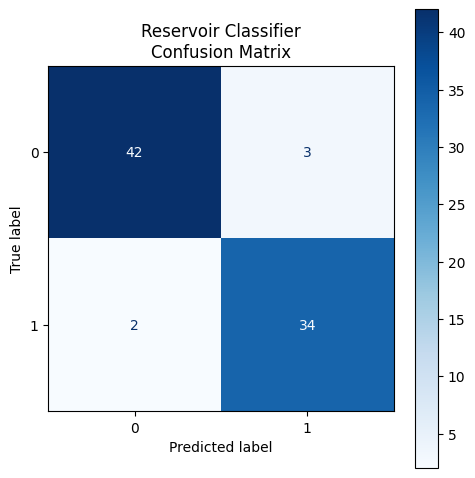

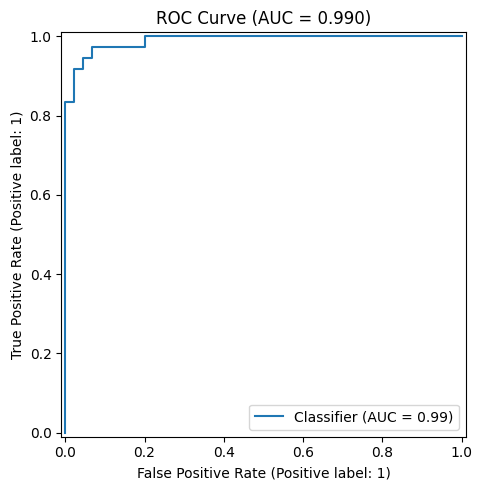

ROC-AUC Score : 0.990


In [ ]:

#   evaluation of the Reservoir Classifier


print("=" * 70)
print("RESERVOIR CLASSIFIER PERFORMANCE")
print("=" * 70)

print("\nClassification Report\n")
print(classification_report(
    res_results["y_test"],
    res_results["y_pred"],
    digits=3
))


# Confusion Matrix


fig, ax = plt.subplots(figsize=(5,5))

ConfusionMatrixDisplay.from_predictions(
    res_results["y_test"],
    res_results["y_pred"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Reservoir Classifier\nConfusion Matrix")

plt.tight_layout()
plt.show()


# ROC Curve


auc = roc_auc_score(
    res_results["y_test"],
    res_results["y_prob"]
)

fig, ax = plt.subplots(figsize=(6,5))

RocCurveDisplay.from_predictions(
    res_results["y_test"],
    res_results["y_prob"],
    ax=ax
)

ax.set_title(f"ROC Curve (AUC = {auc:.3f})")

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score : {auc:.3f}")

CLASSICAL ML BENCHMARK
Logistic Regression      : 0.952 ± 0.009
SVM (RBF)                : 0.956 ± 0.019
Random Forest            : 0.941 ± 0.022
MLP                      : 0.944 ± 0.033


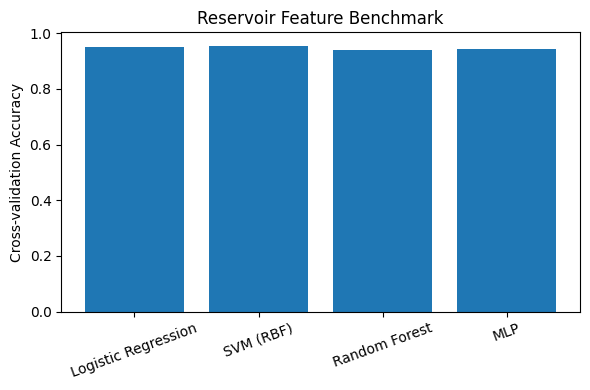

In [ ]:

# Benchmark against Classical ML Models


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "SVM (RBF)":
        SVC(kernel="rbf", probability=True),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=0,
            class_weight="balanced"),

    "MLP":
        MLPClassifier(
            hidden_layer_sizes=(64,32),
            max_iter=3000,
            random_state=0)
}

print("="*70)
print("CLASSICAL ML BENCHMARK")
print("="*70)

benchmark_results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    scores = cross_val_score(
        pipe,
        X_res,
        y_phase,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=0),
        scoring="accuracy"
    )

    benchmark_results[name] = scores.mean()

    print(f"{name:25s}: {scores.mean():.3f} ± {scores.std():.3f}")

plt.figure(figsize=(6,4))

plt.bar(
    benchmark_results.keys(),
    benchmark_results.values()
)

plt.ylabel("Cross-validation Accuracy")

plt.title("Reservoir Feature Benchmark")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [ ]:
print(np.mean(X_test))
print(np.std(X_test))

3.338442262124016
6.400553447056666


In [ ]:
for sigma in noise_levels:

    X_noisy = X_test + rng.normal(
        0,
        sigma,
        X_test.shape
    )



    y_pred = clf.predict(X_noisy)

    acc = accuracy_score(y_test, y_pred)

    noise_acc.append(acc)

    print(f"Noise σ = {sigma:.2f} : Accuracy = {acc:.3f}")

Noise σ = 0.00 : Accuracy = 0.938
Noise σ = 0.01 : Accuracy = 0.951
Noise σ = 0.02 : Accuracy = 0.951
Noise σ = 0.05 : Accuracy = 0.938
Noise σ = 0.10 : Accuracy = 0.926


FEATURE IMPORTANCE
Total number of features : 15


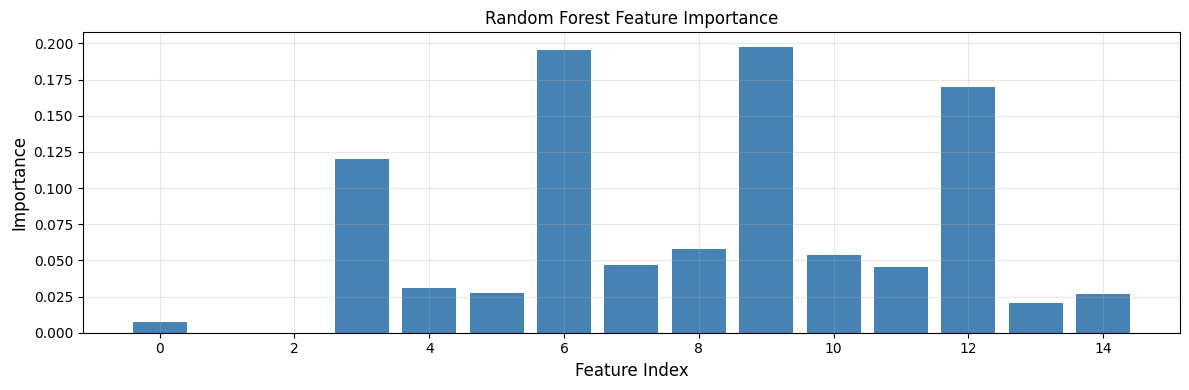


Top 10 Features

 1. Feature  9 | Time =  4 | log(Survival Probability)    | Importance = 0.19775
 2. Feature  6 | Time =  2 | log(Survival Probability)    | Importance = 0.19555
 3. Feature 12 | Time =  8 | log(Survival Probability)    | Importance = 0.17014
 4. Feature  3 | Time =  1 | log(Survival Probability)    | Importance = 0.11975
 5. Feature  8 | Time =  2 | <Sz(site 4)>                 | Importance = 0.05814
 6. Feature 10 | Time =  4 | <Sz(site 0)>                 | Importance = 0.05366
 7. Feature  7 | Time =  2 | <Sz(site 0)>                 | Importance = 0.04701
 8. Feature 11 | Time =  4 | <Sz(site 4)>                 | Importance = 0.04517
 9. Feature  4 | Time =  1 | <Sz(site 0)>                 | Importance = 0.03100
10. Feature  5 | Time =  1 | <Sz(site 4)>                 | Importance = 0.02731


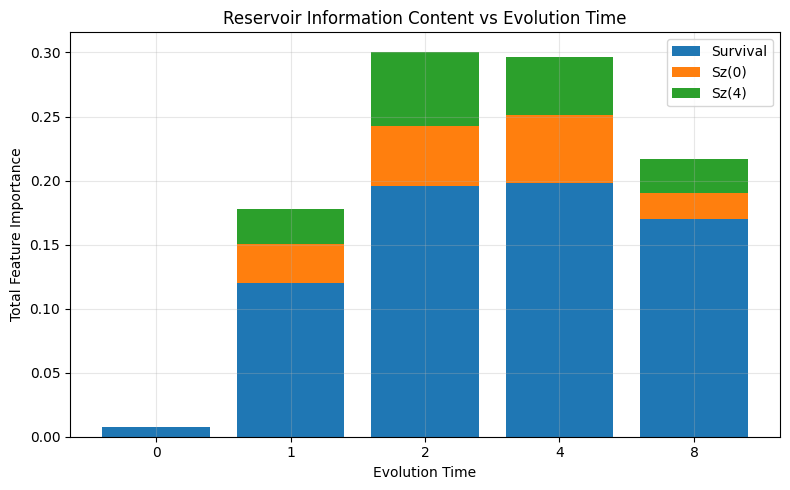

In [ ]:

# Feature Importance Analysis

meas_times = (0, 1, 2, 4, 8)
rf = res_results["classifier"]

importance = rf.feature_importances_

print("=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(f"Total number of features : {len(importance)}")


# Raw Feature Importance


plt.figure(figsize=(12,4))

plt.bar(
    np.arange(len(importance)),
    importance,
    color="steelblue"
)

plt.xlabel("Feature Index", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.title("Random Forest Feature Importance")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Top Features


top = np.argsort(importance)[::-1]

print("\nTop 10 Features\n")

for rank, idx in enumerate(top[:10],1):

    t_index = idx // 3

    obs = idx % 3

    if obs == 0:
        observable = "log(Survival Probability)"
    elif obs == 1:
        observable = f"<Sz(site {0})>"
    else:
        observable = f"<Sz(site {N//2})>"

    print(
        f"{rank:2d}. Feature {idx:2d} | "
        f"Time = {meas_times[t_index]:2d} | "
        f"{observable:28s} | "
        f"Importance = {importance[idx]:.5f}"
    )


# Importance grouped by evolution time


importance_time = importance.reshape(len(meas_times),3)

labels = [
    "Survival",
    f"Sz({0})",
    f"Sz({N//2})"
]

plt.figure(figsize=(8,5))

bottom = np.zeros(len(meas_times))

for j in range(3):

    plt.bar(
        np.arange(len(meas_times)),
        importance_time[:,j],
        bottom=bottom,
        label=labels[j]
    )

    bottom += importance_time[:,j]

plt.xticks(
    np.arange(len(meas_times)),
    meas_times
)

plt.xlabel("Evolution Time")

plt.ylabel("Total Feature Importance")

plt.title("Reservoir Information Content vs Evolution Time")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

SHAP FEATURE IMPORTANCE


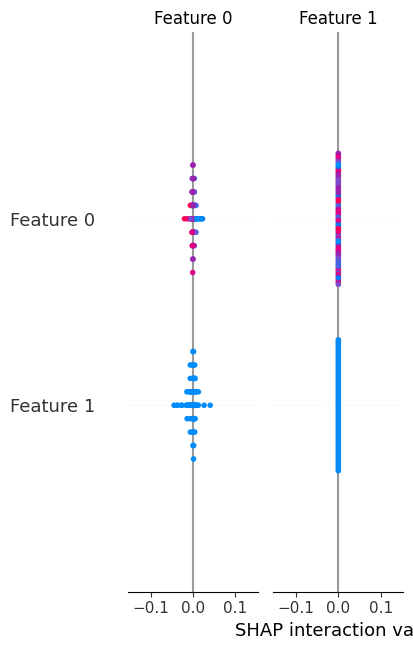

In [ ]:

# SHAP Explainability


import shap

explainer = shap.TreeExplainer(res_results["classifier"])

shap_values = explainer.shap_values(
    res_results["X_test"]
)

print("="*70)
print("SHAP FEATURE IMPORTANCE")
print("="*70)

shap.summary_plot(
    shap_values,
    res_results["X_test"],
    show=False
)

plt.tight_layout()

plt.show()

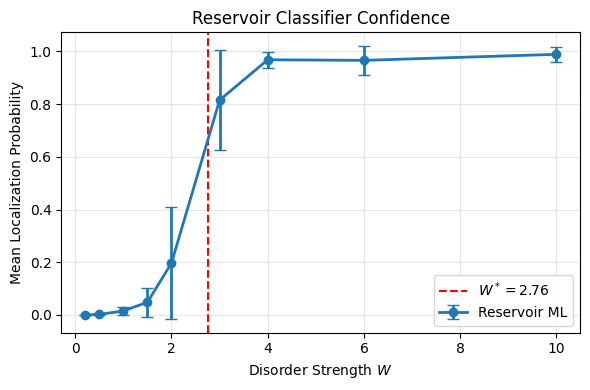

In [ ]:

# ML Probability vs Disorder Strength


# Probability that a sample belongs to the localized phase

clf = res_results["classifier"]
scaler = res_results["scaler"]

W_unique = np.sort(np.unique(y_W))

ml_prob = []
ml_std = []

for W in W_unique:

    mask = (y_W == W)

    XW = scaler.transform(X_res[mask])

    prob = clf.predict_proba(XW)[:,1]

    ml_prob.append(prob.mean())
    ml_std.append(prob.std())

ml_prob = np.array(ml_prob)
ml_std = np.array(ml_std)

plt.figure(figsize=(6,4))

plt.errorbar(
    W_unique,
    ml_prob,
    yerr=ml_std,
    fmt='o-',
    capsize=4,
    linewidth=2,
    label="Reservoir ML"
)

plt.axvline(
    W_star,
    color='red',
    linestyle='--',
    label=f"$W^*={W_star:.2f}$"
)

plt.xlabel("Disorder Strength $W$")
plt.ylabel("Mean Localization Probability")
plt.title("Reservoir Classifier Confidence")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

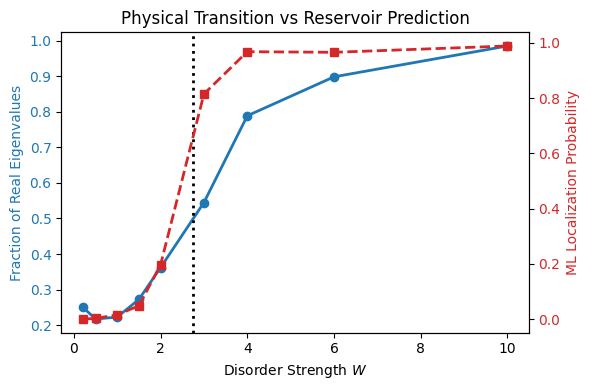

In [ ]:

# Compare ML Prediction with Physical Order Parameter


fig, ax1 = plt.subplots(figsize=(6,4))

ax1.plot(
    W_unique,
    fr_mean,
    'o-',
    color='tab:blue',
    linewidth=2,
    label="Fraction of Real Eigenvalues"
)

ax1.set_xlabel("Disorder Strength $W$")
ax1.set_ylabel("Fraction of Real Eigenvalues",
               color='tab:blue')

ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

ax2.plot(
    W_unique,
    ml_prob,
    's--',
    color='tab:red',
    linewidth=2,
    label="ML Localization Probability"
)

ax2.set_ylabel(
    "ML Localization Probability",
    color='tab:red'
)

ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.axvline(
    W_star,
    color='black',
    linestyle=':',
    linewidth=2
)

plt.title("Physical Transition vs Reservoir Prediction")

fig.tight_layout()

plt.show()


In [ ]:
print("="*70)
print("SURVIVAL CHANNEL ABLATION")
print("="*70)

X_res_spin, _, _, _ = build_dataset(
    N=N,
    g=g,
    n_real=30,
    meas_times=meas_times,
    include_survival=False
)

spin_results = eval_classifier(
    X_res_spin,
    "Reservoir without Survival Channel"
)

print("\nAccuracy Comparison")

print(f"Full Reservoir      : {acc_res:.3f}")
print(f"Spin-only Reservoir : {spin_results['accuracy']:.3f}")

SURVIVAL CHANNEL ABLATION
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Reservoir without Survival Channel  Accuracy = 0.864
Cross-validation (5-fold): 0.878 ± 0.019

Accuracy Comparison
Full Reservoir      : 0.938
Spin-only Reservoir : 0.864


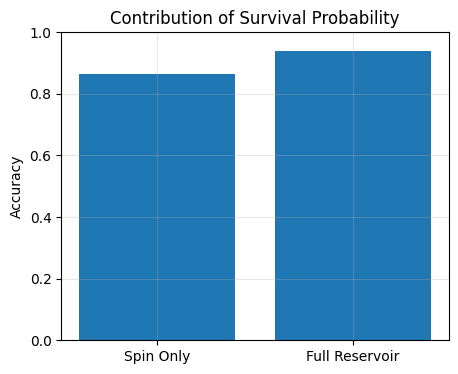

In [ ]:
labels = [
    "Spin Only",
    "Full Reservoir"
]

acc = [
    spin_results["accuracy"],
    acc_res
]

plt.figure(figsize=(5,4))

plt.bar(labels, acc)

plt.ylabel("Accuracy")

plt.title("Contribution of Survival Probability")

plt.ylim(0,1)

plt.grid(alpha=0.3)

plt.show()

GENERALIZATION ACROSS INTERACTION STRENGTH
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Train g=0.30  Test g=0.10 : 0.444
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Train g=0.30  Test g=0.20 : 0.785
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Train g=0.30  Test g=0.40 : 0.904
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Train g=0.30  Test g=0.50 : 0.826


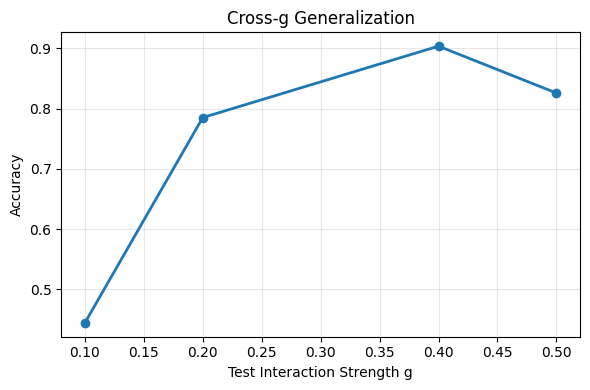

In [ ]:

# Generalization Across Interaction Strength


print("="*70)
print("GENERALIZATION ACROSS INTERACTION STRENGTH")
print("="*70)

g_train = 0.30

g_test_list = [0.10,0.20,0.40,0.50]

X_train, _, fr_train, W_train = build_dataset(
    N=N,
    g=g_train,
    n_real=30
)

y_train = (W_train > W_star).astype(int)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=0,
        class_weight="balanced"))
])

pipe.fit(X_train,y_train)

generalization = []

for gtest in g_test_list:

    X_test, _, fr_test, W_test = build_dataset(
        N=N,
        g=gtest,
        n_real=30
    )

    y_test = (W_test > W_star).astype(int)

    acc = pipe.score(
        X_test,
        y_test
    )

    generalization.append(acc)

    print(f"Train g={g_train:.2f}  Test g={gtest:.2f} : {acc:.3f}")

plt.figure(figsize=(6,4))

plt.plot(
    g_test_list,
    generalization,
    "o-",
    linewidth=2
)

plt.xlabel("Test Interaction Strength g")

plt.ylabel("Accuracy")

plt.title("Cross-g Generalization")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

RESERVOIR SEPARABILITY (PCA)
Explained variance (PC1): 53.08%
Explained variance (PC2): 18.44%
Total explained variance: 71.52%


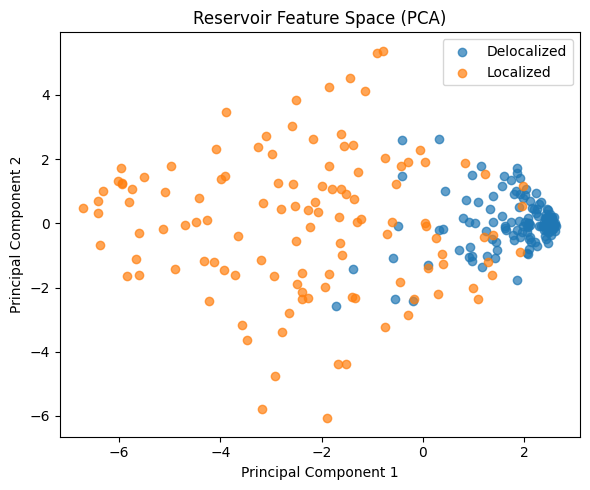

In [ ]:

# Reservoir Separability using PCA


from sklearn.decomposition import PCA

print("="*70)
print("RESERVOIR SEPARABILITY (PCA)")
print("="*70)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# Reduce to two principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance (PC1): {100*pca.explained_variance_ratio_[0]:.2f}%")
print(f"Explained variance (PC2): {100*pca.explained_variance_ratio_[1]:.2f}%")
print(f"Total explained variance: {100*np.sum(pca.explained_variance_ratio_):.2f}%")

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[y_phase==0,0],
    X_pca[y_phase==0,1],
    alpha=0.7,
    label="Delocalized"
)

plt.scatter(
    X_pca[y_phase==1,0],
    X_pca[y_phase==1,1],
    alpha=0.7,
    label="Localized"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Reservoir Feature Space (PCA)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
pip install umap-learn

RESERVOIR SEPARABILITY (UMAP)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


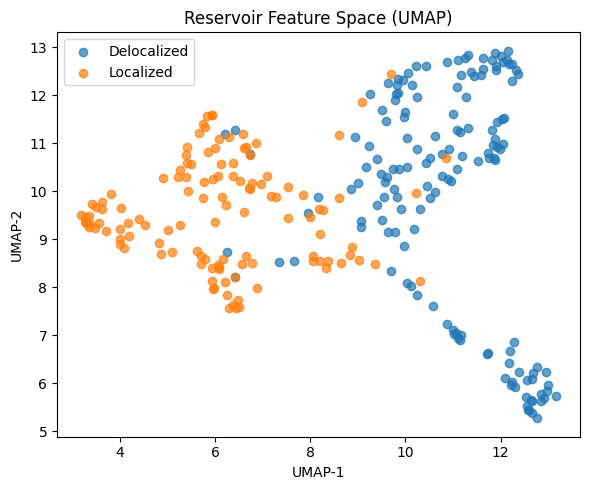

In [ ]:

# Reservoir Separability using UMAP


import umap.umap_ as umap

print("="*70)
print("RESERVOIR SEPARABILITY (UMAP)")
print("="*70)

embedding = umap.UMAP(
    n_neighbors=15,
    min_dist=0.15,
    random_state=0
)

X_umap = embedding.fit_transform(X_scaled)

plt.figure(figsize=(6,5))

plt.scatter(
    X_umap[y_phase==0,0],
    X_umap[y_phase==0,1],
    alpha=0.7,
    label="Delocalized"
)

plt.scatter(
    X_umap[y_phase==1,0],
    X_umap[y_phase==1,1],
    alpha=0.7,
    label="Localized"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.title("Reservoir Feature Space (UMAP)")

plt.legend()

plt.tight_layout()

plt.show()

MINIMAL OBSERVABLE ANALYSIS
Full Reservoir           : 0.956
Survival only            : 0.956
Sz(0) only               : 0.809
Sz(mid) only             : 0.750
Early times only         : 0.912
Late times only          : 0.956


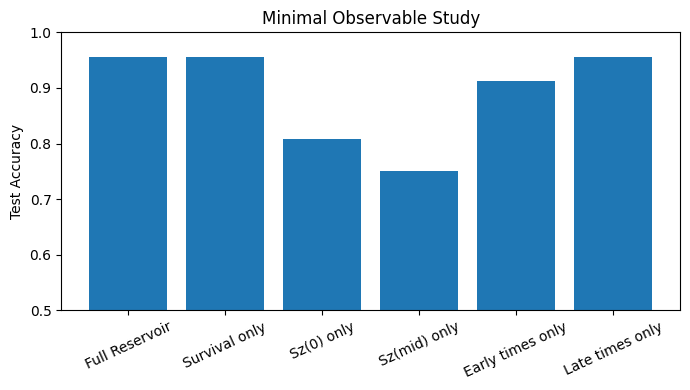

In [ ]:

# Minimal Observable Analysis


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

print("="*70)
print("MINIMAL OBSERVABLE ANALYSIS")
print("="*70)


# Feature indices
# Feature order:
# [logP, Sz(0), Sz(mid)] repeated for each measurement time

n_times = 5

logP_idx = [3*i for i in range(n_times)]
sz0_idx  = [3*i + 1 for i in range(n_times)]
szm_idx  = [3*i + 2 for i in range(n_times)]

early_idx = [0,1,2,3,4,5]            # t = 0,1
late_idx  = [9,10,11,12,13,14]       # t = 4,8

feature_sets = {
    "Full Reservoir"      : np.arange(X_res.shape[1]),
    "Survival only"       : logP_idx,
    "Sz(0) only"          : sz0_idx,
    "Sz(mid) only"        : szm_idx,
    "Early times only"    : early_idx,
    "Late times only"     : late_idx,
}

results = {}

for name, idx in feature_sets.items():

    X = X_res[:, idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_phase,
        test_size=0.25,
        stratify=y_phase,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=0
        ))
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(f"{name:25s}: {acc:.3f}")


# Plot


plt.figure(figsize=(7,4))

plt.bar(results.keys(), results.values())

plt.ylabel("Test Accuracy")

plt.title("Minimal Observable Study")

plt.xticks(rotation=25)

plt.ylim(0.5,1.0)

plt.tight_layout()

plt.show()

TIME-RESOLVED RESERVOIR INFORMATION
t =  0 : Accuracy = 0.544
t =  1 : Accuracy = 0.897
t =  2 : Accuracy = 0.897
t =  4 : Accuracy = 0.956
t =  8 : Accuracy = 0.941


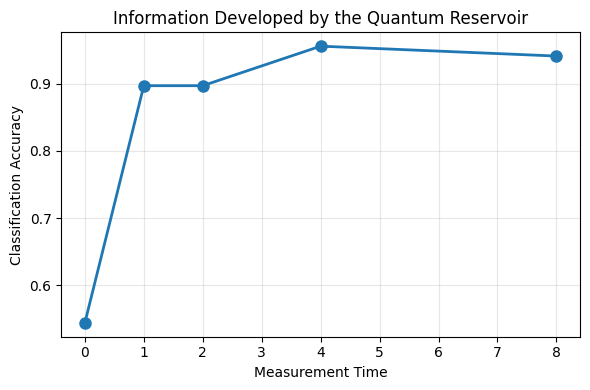

In [ ]:

# Time-Resolved Reservoir Information


print("="*70)
print("TIME-RESOLVED RESERVOIR INFORMATION")
print("="*70)

times = [0,1,2,4,8]

accuracy_vs_time = []

for i,t in enumerate(times):

    cols = [3*i,3*i+1,3*i+2]

    X = X_res[:,cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_phase,
        test_size=0.25,
        stratify=y_phase,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=0
        ))
    ])

    pipe.fit(X_train,y_train)

    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test,pred)

    accuracy_vs_time.append(acc)

    print(f"t = {t:2d} : Accuracy = {acc:.3f}")

plt.figure(figsize=(6,4))

plt.plot(
    times,
    accuracy_vs_time,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel("Measurement Time")

plt.ylabel("Classification Accuracy")

plt.title("Information Developed by the Quantum Reservoir")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

FEATURE-SPACE SEPARATION
t= 0   distance = 0.0000
t= 1   distance = 0.7032
t= 2   distance = 2.3882
t= 4   distance = 6.1637
t= 8   distance = 13.8929


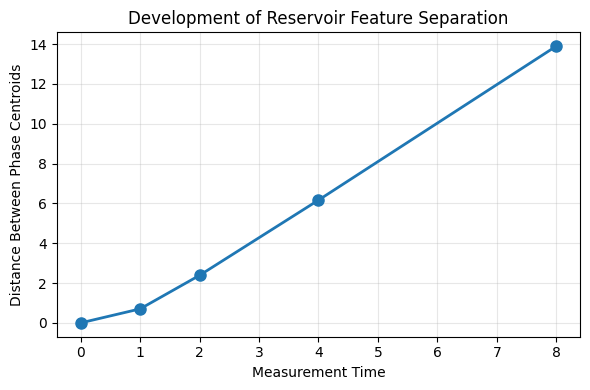

In [ ]:

# Feature Space Separation vs Time


print("="*70)
print("FEATURE-SPACE SEPARATION")
print("="*70)

times = [0,1,2,4,8]

distance = []

for i in range(len(times)):

    cols = [3*i,3*i+1,3*i+2]

    X = X_res[:,cols]

    loc = X[y_phase==1]
    deloc = X[y_phase==0]

    mu_loc = loc.mean(axis=0)
    mu_deloc = deloc.mean(axis=0)

    d = np.linalg.norm(mu_loc-mu_deloc)

    distance.append(d)

    print(f"t={times[i]:2d}   distance = {d:.4f}")

plt.figure(figsize=(6,4))

plt.plot(
    times,
    distance,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel("Measurement Time")

plt.ylabel("Distance Between Phase Centroids")

plt.title("Development of Reservoir Feature Separation")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

FINITE-SIZE SCALING

Running N = 8
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
W*(N=8) = 2.755

Running N = 10
Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
W*(N=10) = 3.356


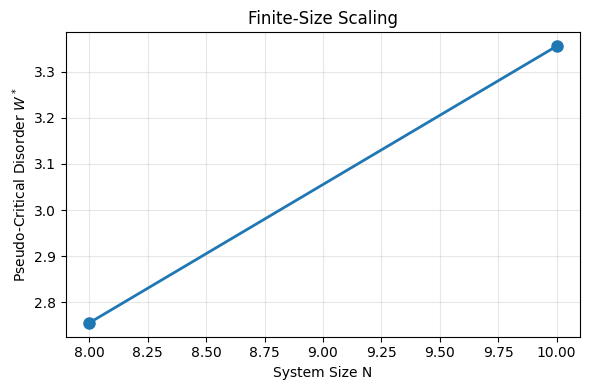

In [ ]:

# Finite-Size Scaling of the Pseudo-Critical Disorder


print("="*70)
print("FINITE-SIZE SCALING")
print("="*70)

sizes = [8, 10]

W_star_list = []

for Nsize in sizes:

    print(f"\nRunning N = {Nsize}")

    X_tmp, Xo_tmp, y_fr_tmp, y_W_tmp = build_dataset(
        N=Nsize,
        g=0.3,
        n_real=30
    )

    W_grid_tmp = np.unique(y_W_tmp)

    fr_mean = np.array([
        y_fr_tmp[y_W_tmp==W].mean()
        for W in W_grid_tmp
    ])

    above = fr_mean > 0.5

    if above.all() or (~above).all():

        W_star_tmp = np.median(W_grid_tmp)

    else:

        cross = np.where(~above[:-1] & above[1:])[0][0]

        w1 = W_grid_tmp[cross]
        w2 = W_grid_tmp[cross+1]

        f1 = fr_mean[cross]
        f2 = fr_mean[cross+1]

        W_star_tmp = w1 + (0.5-f1)*(w2-w1)/(f2-f1)

    W_star_list.append(W_star_tmp)

    print(f"W*(N={Nsize}) = {W_star_tmp:.3f}")

plt.figure(figsize=(6,4))

plt.plot(
    sizes,
    W_star_list,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel("System Size N")

plt.ylabel("Pseudo-Critical Disorder $W^*$")

plt.title("Finite-Size Scaling")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()